<a href="https://colab.research.google.com/github/ancestor9/2026_Fall_Deep-Learning-with-Python/blob/main/scripts/chapter13_timeseries_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [2]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.31.0 which is incompatible.


In [3]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [4]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Timeseries forecasting

### Different kinds of timeseries tasks

### A temperature forecasting example

In [5]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-08-14 09:07:30--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.216.28.6, 52.217.64.174, 54.231.225.120, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.216.28.6|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  23.0MB/s    in 0.6s    

2026-08-14 09:07:31 (23.0 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [6]:
import os

fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [7]:
import pandas as pd
pd.read_csv(fname)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420446,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420447,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420448,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420449,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8


In [8]:
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

In [9]:
temperature

array([-8.02, -8.41, -8.51, ..., -3.16, -4.23, -4.82])

In [10]:
raw_data

array([[ 9.9652e+02, -8.0200e+00,  2.6540e+02, ...,  1.0300e+00,
         1.7500e+00,  1.5230e+02],
       [ 9.9657e+02, -8.4100e+00,  2.6501e+02, ...,  7.2000e-01,
         1.5000e+00,  1.3610e+02],
       [ 9.9653e+02, -8.5100e+00,  2.6491e+02, ...,  1.9000e-01,
         6.3000e-01,  1.7160e+02],
       ...,
       [ 9.9982e+02, -3.1600e+00,  2.7001e+02, ...,  1.0800e+00,
         2.0000e+00,  2.1520e+02],
       [ 9.9981e+02, -4.2300e+00,  2.6894e+02, ...,  1.4900e+00,
         2.1600e+00,  2.2580e+02],
       [ 9.9982e+02, -4.8200e+00,  2.6836e+02, ...,  1.2300e+00,
         1.9600e+00,  1.8490e+02]])

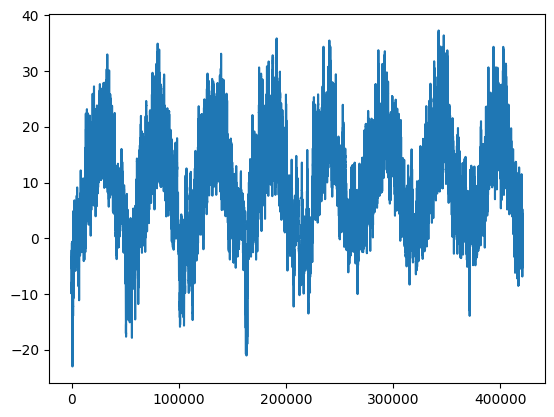

In [11]:
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)

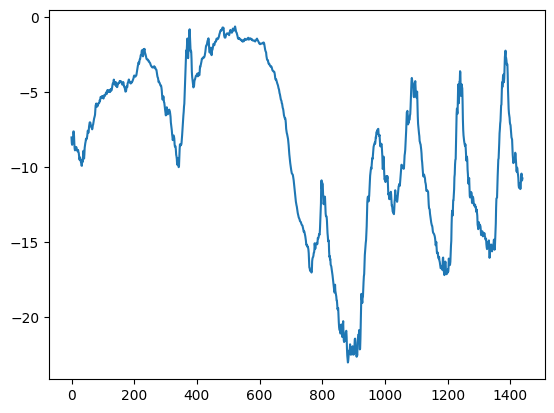

In [12]:
plt.plot(range(1440), temperature[:1440])

In [13]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


## **[Start] Timesereis Data Preprocessing**
### **1. single variate with single-step sliding window**

In [13]:
import keras

dataset = keras.utils.timeseries_dataset_from_array(
    data=temperature[:-1],      # x_i = T_i  (마지막 값 제외)
    targets=temperature[1:],    # y_i = T_{i+1}  (첫 값 제외)
    sequence_length=1,          # 입력 윈도우 길이 L=1
    sampling_rate=1,
    batch_size=1,
)

In [14]:
for i, (inputs, targets) in enumerate(dataset.take(5)):
    print(f"Sample {i+1}:")
    print(f"  Input (temperature[:-1]): {inputs.numpy().flatten()}")
    print(f"  Target (temperature[1:]): {targets.numpy().flatten()}")


Sample 1:
  Input (temperature[:-1]): [-8.02]
  Target (temperature[1:]): [-8.41]
Sample 2:
  Input (temperature[:-1]): [-8.41]
  Target (temperature[1:]): [-8.51]
Sample 3:
  Input (temperature[:-1]): [-8.51]
  Target (temperature[1:]): [-8.31]
Sample 4:
  Input (temperature[:-1]): [-8.31]
  Target (temperature[1:]): [-8.27]
Sample 5:
  Input (temperature[:-1]): [-8.27]
  Target (temperature[1:]): [-8.05]


### **2. multiple variates with single-step sliding window**

In [15]:
import numpy as np
import keras

# Extract unscaled 'wv' data, similar to how 'temperature' was extracted.
# 'wv (m/s)' is at index 12 in the original header (including 'Date Time').
wv_data = np.array([float(line.split(",")[header.index('"wv (m/s)"')]) for line in lines])

X_features = np.stack([temperature, wv_data], axis=-1)

multi_variate_dataset = keras.utils.timeseries_dataset_from_array(
    data=X_features[:-1],      # Input features (temperature at time t, wv at time t)
    targets=wv_data[1:],        # Target (wv at time t+1)
    sequence_length=1,          # Input window length L=1
    sampling_rate=1,
    batch_size=1,
)

print("Multi-variate dataset created successfully.")
for inputs, targets in multi_variate_dataset.take(5):
    print(f"Inputs shape: {inputs.shape}, Targets shape: {targets.shape}")
    print(f"Example Input: {inputs.numpy().flatten()}")
    print(f"Example Target: {targets.numpy().flatten()}")

Multi-variate dataset created successfully.
Inputs shape: (1, 1, 2), Targets shape: (1,)
Example Input: [-8.02  1.03]
Example Target: [0.72]
Inputs shape: (1, 1, 2), Targets shape: (1,)
Example Input: [-8.41  0.72]
Example Target: [0.19]
Inputs shape: (1, 1, 2), Targets shape: (1,)
Example Input: [-8.51  0.19]
Example Target: [0.34]
Inputs shape: (1, 1, 2), Targets shape: (1,)
Example Input: [-8.31  0.34]
Example Target: [0.32]
Inputs shape: (1, 1, 2), Targets shape: (1,)
Example Input: [-8.27  0.32]
Example Target: [0.21]


In [16]:
import numpy as np
import keras

# Input features: (current temperature, current wv_data)
X_features_multi_output = np.stack([temperature, wv_data], axis=-1)

# Target features: (next temperature, next wv_data)
Y_targets_multi_output = np.stack([temperature[1:], wv_data[1:]], axis=-1)

# Create the dataset with multiple outputs
multi_output_dataset = keras.utils.timeseries_dataset_from_array(
    data=X_features_multi_output[:-1],  # Inputs (temperature at t, wv at t)
    targets=Y_targets_multi_output,      # Targets (temperature at t+1, wv at t+1)
    sequence_length=1,                   # Single-step prediction
    sampling_rate=1,
    batch_size=1,
)

print("Multi-output dataset created successfully.")

# Inspect a sample from this new dataset
for inputs, targets in multi_output_dataset.take(5):
    print(f"Inputs shape: {inputs.shape}, Targets shape: {targets.shape}")
    print(f"Example Input: {inputs.numpy().flatten()}")
    print(f"Example Target: {targets.numpy().flatten()}")


Multi-output dataset created successfully.
Inputs shape: (1, 1, 2), Targets shape: (1, 2)
Example Input: [-8.02  1.03]
Example Target: [-8.41  0.72]
Inputs shape: (1, 1, 2), Targets shape: (1, 2)
Example Input: [-8.41  0.72]
Example Target: [-8.51  0.19]
Inputs shape: (1, 1, 2), Targets shape: (1, 2)
Example Input: [-8.51  0.19]
Example Target: [-8.31  0.34]
Inputs shape: (1, 1, 2), Targets shape: (1, 2)
Example Input: [-8.31  0.34]
Example Target: [-8.27  0.32]
Inputs shape: (1, 1, 2), Targets shape: (1, 2)
Example Input: [-8.27  0.32]
Example Target: [-8.05  0.21]


<img src ="https://deeplearningwithpython.io/images/ch02/timeseries_data.a711cc5a.png">

## **[End] Timesereis Data Preprocessing**

#### **Preparing the data**

In [14]:
# @title **keras.utils.timeseries_dataset_from_array()** 이해하기

import numpy as np
import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3], # [0,1,2,3,4,5,6]  ← 뒤 3개(7,8,9)는 제외됨
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


In [15]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

### 시계열 원본자료 구성 방법
- raw_data[:-delay],           # 입력 후보
- targets=temperature[delay:], # 정답 후보
- sampling_rate=sampling_rate, # 6개마다 1개씩 (1시간 간격)
- sequence_length=sequence_length, # 윈도우 길이 120 (=5일치)
- shuffle=True,
- batch_size=batch_size,       # 256개씩 묶음

In [16]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

In [17]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


#### A commonsense, non-machine-learning baseline
- **모델 없이 그냥 마지막 관측값을 그대로 미래 예측치로 쓰면 오차가 얼마나 되는가"** 를 계산하는, 신경망과 비교할 **baseline(기준선)**

In [18]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


#### Let's try a basic machine learning model
- **가장 단순한 완전연결(Dense) 신경망으로 예측**

In [23]:
import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 59s 69ms/step - loss: 14.4412 - mae: 2.8940 - val_loss: 10.6115 - val_mae: 2.5628
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 66ms/step - loss: 9.1120 - mae: 2.3717 - val_loss: 11.0403 - val_mae: 2.6305
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 68ms/step - loss: 8.2849 - mae: 2.2627 - val_loss: 10.4665 - val_mae: 2.5674
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 68ms/step - loss: 7.7180 - mae: 2.1900 - val_loss: 10.8657 - val_mae: 2.6151
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 66ms/step - loss: 7.3024 - mae: 2.1332 - val_loss: 10.8333 - val_mae: 2.6128
405/405 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - loss: 11.6876 - mae: 2.6861
Test MAE: 2.69


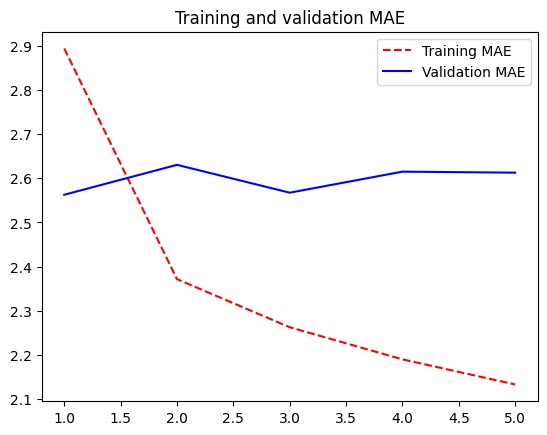

In [24]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

#### Let's try a 1D convolutional model

In [25]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 86s 98ms/step - loss: 21.4447 - mae: 3.6106 - val_loss: 15.2457 - val_mae: 3.1065
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 77s 94ms/step - loss: 14.0133 - mae: 2.9771 - val_loss: 14.9102 - val_mae: 3.0817
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 76s 92ms/step - loss: 12.8492 - mae: 2.8515 - val_loss: 15.0927 - val_mae: 3.0745
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 77s 94ms/step - loss: 11.9479 - mae: 2.7466 - val_loss: 14.9557 - val_mae: 3.0574
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 77s 93ms/step - loss: 11.3040 - mae: 2.6675 - val_loss: 14.6707 - val_mae: 3.0265
405/405 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - loss: 15.6364 - mae: 3.1307
Test MAE: 3.13


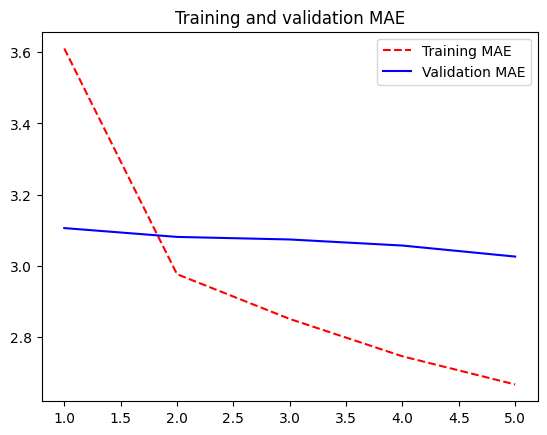

In [26]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### Recurrent neural networks

In [27]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm.keras")

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 86s 103ms/step - loss: 39.9817 - mae: 4.6552 - val_loss: 15.5772 - val_mae: 2.9409
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 136s 97ms/step - loss: 13.4084 - mae: 2.7909 - val_loss: 10.8068 - val_mae: 2.5290
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 80s 97ms/step - loss: 10.7249 - mae: 2.5436 - val_loss: 9.8624 - val_mae: 2.4398
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 80s 97ms/step - loss: 10.0179 - mae: 2.4675 - val_loss: 9.6888 - val_mae: 2.4191
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 79s 97ms/step - loss: 9.6001 - mae: 2.4177 - val_loss: 9.2610 - val_mae: 2.3641
Test MAE: {model.evaluate(test_dataset)[1]:.2f}


In [29]:
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 10.9943 - mae: 2.6056
Test MAE: 2.61


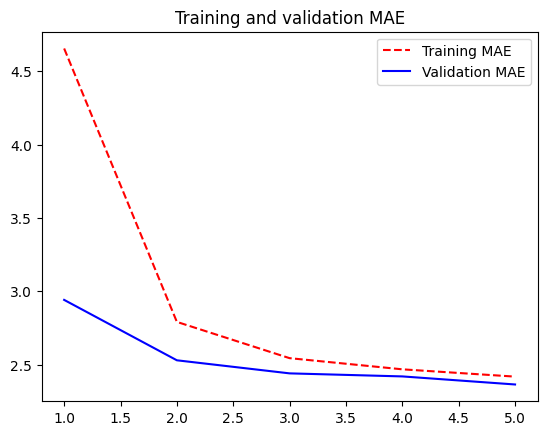

In [28]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

#### Understanding recurrent neural networks

In [19]:
import numpy as np

timesteps = 100
input_features = 32
output_features = 64
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features,))
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []
for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t
final_output_sequence = np.concatenate(successive_outputs, axis=0)

In [ ]:
print(f'inputs : {inputs.shape}')
print(f'state_t : {state_t.shape}')
print(f'W : {W.shape}')
print(f'U : {U.shape}')
print(f'b : {b.shape}')

inputs : (100, 32)
state_t : (64,)
W : (64, 32)
U : (64, 64)
b : (64,)


In [ ]:
for input_t in inputs:
    print(f'input_t : {input_t.shape}')
    break

ts = 0
for input_t in inputs:
    ts += 1
print(f'input_t_{ts} : {input_t.shape}')

input_t : (32,)
input_t_100 : (32,)


#### A recurrent layer in Keras

In [21]:
import keras
from keras import layers

num_features = 14
inputs = keras.Input(shape=(None, num_features))
outputs = layers.SimpleRNN(16)(inputs)

In [22]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
print(outputs.shape)

(None, 16)


In [23]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)
print(outputs.shape)

(None, 120, 16)


In [24]:
inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16)(x)

#### Getting the most out of recurrent neural networks

#### Using recurrent dropout to fight overfitting

In [27]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 56ms/step - loss: 31.8820 - mae: 4.1677 - val_loss: 11.2556 - val_mae: 2.5760
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 16.3497 - mae: 3.1370 - val_loss: 9.8141 - val_mae: 2.4286
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 15.3442 - mae: 3.0386 - val_loss: 9.3167 - val_mae: 2.3722
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - loss: 14.6663 - mae: 2.9708 - val_loss: 9.1637 - val_mae: 2.3564
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 14.1686 - mae: 2.9203 - val_loss: 9.1255 - val_mae: 2.3448


In [29]:
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - loss: 10.3750 - mae: 2.5196
Test MAE: 2.52


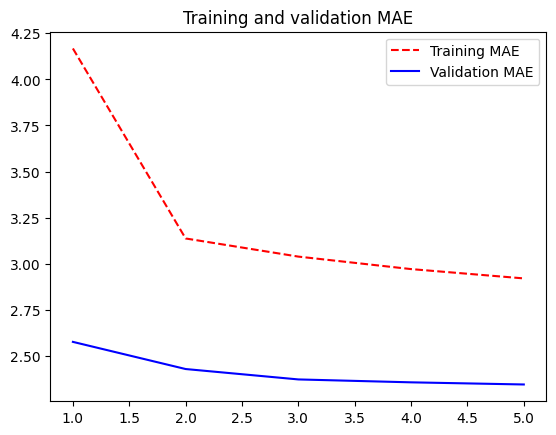

In [28]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

#### Stacking recurrent layers

In [32]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 64ms/step - loss: 31.5891 - mae: 4.1390 - val_loss: 11.4192 - val_mae: 2.5520
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 15.1890 - mae: 3.0093 - val_loss: 9.3090 - val_mae: 2.3441
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 14.0403 - mae: 2.8995 - val_loss: 8.9027 - val_mae: 2.3033
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 13.4845 - mae: 2.8450 - val_loss: 8.8608 - val_mae: 2.3017
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 12.9946 - mae: 2.7942 - val_loss: 8.9365 - val_mae: 2.3164
405/405 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 9.8668 - mae: 2.4485
Test MAE: 2.45


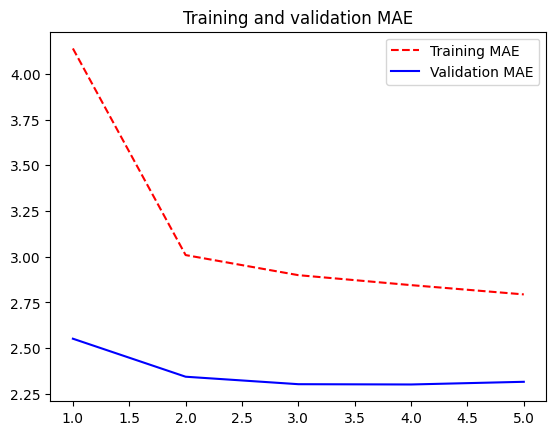

In [33]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

#### Using bidirectional RNNs

In [34]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 58s 69ms/step - loss: 76.6087 - mae: 7.0172 - val_loss: 49.2891 - val_mae: 5.7044
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 53.7330 - mae: 5.8483 - val_loss: 40.0561 - val_mae: 5.0753
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 36.9454 - mae: 4.7548 - val_loss: 25.9734 - val_mae: 3.9136
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 21.4613 - mae: 3.6096 - val_loss: 17.5969 - val_mae: 3.2666
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - loss: 21.9569 - mae: 3.7024 - val_loss: 18.7568 - val_mae: 3.4043


In [35]:
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - loss: 21.8582 - mae: 3.6749
Test MAE: 3.67


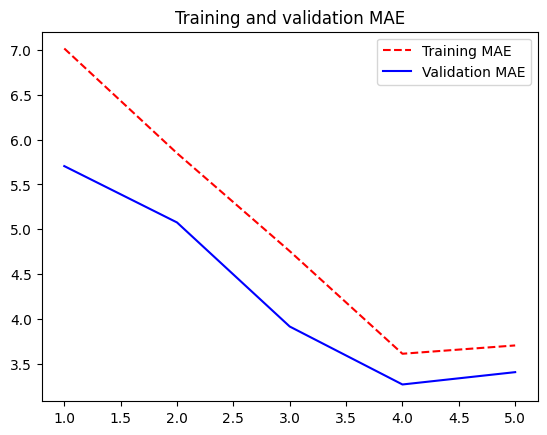

In [36]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### Going even further